In [97]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.naive_bayes import MultinomialNB

In [2]:
df = pd.read_csv('../data/IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.shape

(50000, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
df.describe().T

,count,unique,top,freq
review,50000,49582,Loved today's show!!! It was a variety and not...,5
sentiment,50000,2,positive,25000


In [6]:
duplicates = df[df.duplicated(subset=['review'], keep=False)]
duplicates.sort_values("review")

,review,sentiment
34058,"""Go Fish"" garnered Rose Troche rightly or wron...",negative
47467,"""Go Fish"" garnered Rose Troche rightly or wron...",negative
29956,"""Three"" is a seriously dumb shipwreck movie. M...",negative
31488,"""Three"" is a seriously dumb shipwreck movie. M...",negative
47527,"""Witchery"" might just be the most incoherent a...",negative
...,...,...
47876,this movie sucks. did anyone notice that the e...,negative
44122,"well, the writing was very sloppy, the directi...",negative
23056,"well, the writing was very sloppy, the directi...",negative
10163,"when I first heard about this movie, I noticed...",positive


In [7]:
df.groupby("review")["sentiment"].nunique().value_counts()

sentiment
1    49582
Name: count, dtype: int64

In [8]:
#Remove Duplicate reviews (redundant data)
df.drop_duplicates(subset=['review'], keep='first', inplace=True)

In [9]:
df.shape

(49582, 2)

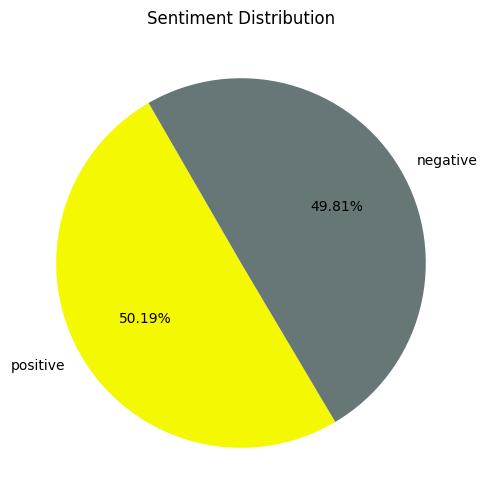

In [10]:
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.2f%%",
    startangle=120,
    colors = ["#f4f800", "#677777"],
)

plt.title("Sentiment Distribution")
plt.show()

In [11]:
sentiment_counts.head()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

In [12]:
for i in range(5): 
    print(f"Review {i+1}:", "\n")
    print(df.iloc[i]["review"], "\n")
    print(f"Sentiment: {df.iloc[i]['sentiment']}", "\n")

Review 1: 

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is du

In [13]:
def no_of_words(text): 
    words  = text.split()
    return len(words)

df["no_of_words"] = df["review"].apply(no_of_words)
df.head()

,review,sentiment,no_of_words
0,One of the other reviewers has mentioned that ...,positive,307
1,A wonderful little production. <br /><br />The...,positive,162
2,I thought this was a wonderful way to spend ti...,positive,166
3,Basically there's a family where a little boy ...,negative,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230


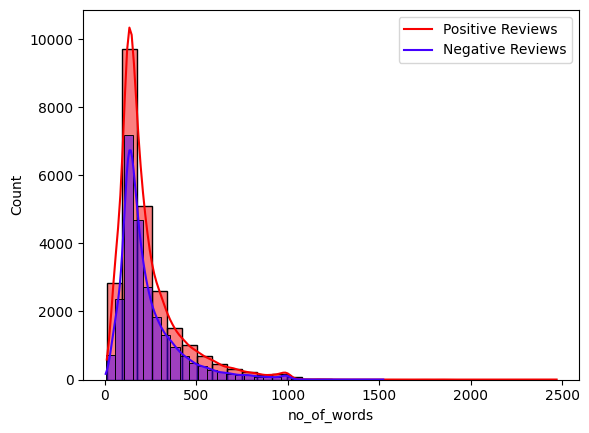

In [14]:
#Histogram of number of words in positive and negative reviews
sns.histplot(df[df["sentiment"]=="positive"]["no_of_words"],color="#f80000", kde=True,bins = 30)
sns.histplot(df[df["sentiment"]=="negative"]["no_of_words"], color="#4400FF", kde=True,bins = 30)
plt.legend(["Positive Reviews", "Negative Reviews"])
plt.show()

In [15]:
#Convert sentiment labels to numerical values for modeling
df["sentiment"].replace({"positive": 1, "negative": 0}, inplace=True)

C:\Users\tanub\AppData\Local\Temp\ipykernel_8440\99305634.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["sentiment"].replace({"positive": 1, "negative": 0}, inplace=True)


In [16]:
df.head()

,review,sentiment,no_of_words
0,One of the other reviewers has mentioned that ...,1,307
1,A wonderful little production. <br /><br />The...,1,162
2,I thought this was a wonderful way to spend ti...,1,166
3,Basically there's a family where a little boy ...,0,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,230


In [17]:
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # remove html tags
    text = re.sub(r'<.*?>', '', text)
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [18]:
df["review"] = df["review"].apply(preprocess_text)

In [19]:
df.head()

,review,sentiment,no_of_words
0,one of the other reviewers has mentioned that ...,1,307
1,a wonderful little production the filming tech...,1,162
2,i thought this was a wonderful way to spend ti...,1,166
3,basically theres a family where a little boy j...,0,138
4,petter matteis love in the time of money is a ...,1,230


In [20]:
df["sentiment"].value_counts(normalize=True) * 100

sentiment
1    50.187568
0    49.812432
Name: proportion, dtype: float64

In [21]:
df.rename(columns = {"review":"cleaned_review"}, inplace = True)

In [22]:
df.head()

,cleaned_review,sentiment,no_of_words
0,one of the other reviewers has mentioned that ...,1,307
1,a wonderful little production the filming tech...,1,162
2,i thought this was a wonderful way to spend ti...,1,166
3,basically theres a family where a little boy j...,0,138
4,petter matteis love in the time of money is a ...,1,230


In [23]:
X = df["cleaned_review"]
y = df["sentiment"]
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [24]:
tfidf = TfidfVectorizer(max_features=10000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [25]:
model = LogisticRegression()
model.fit(X_train_tfidf,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [26]:
params = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "solver": ["liblinear", "newton-cg", "lbfgs", "sag", "saga"],
    "max_iter": [100, 200, 300, 400, 500]
}
random_search = RandomizedSearchCV(model, param_distributions=params, n_iter=10, cv=5, scoring='accuracy', random_state=42,n_jobs = -1)

In [27]:
random_search.fit(X_train_tfidf, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': [0.001, 0.01, ...], 'max_iter': [100, 200, ...], 'solver': ['liblinear', 'newton-cg', ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default val

In [28]:
model = random_search.best_estimator_

In [29]:
y_pred = model.predict(X_test_tfidf)

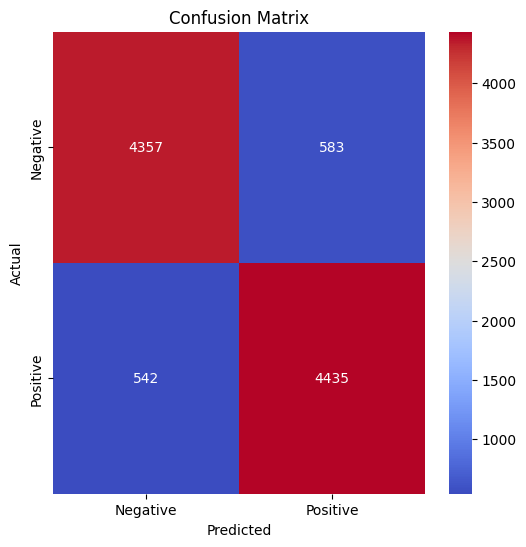

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [31]:
print(accuracy_score(y_test, y_pred))

0.8865584350105878


What were the most important TF-IDF features? 

In [32]:
feature_names = tfidf.get_feature_names_out()
print(feature_names[:100])  # Display the first 100 feature names alphabetically
coefficients = model.coef_[0]

['aaron' 'abandon' 'abandoned' 'abbey' 'abbott' 'abc' 'abilities'
 'ability' 'able' 'ably' 'aboard' 'abomination' 'abortion' 'abound'
 'about' 'above' 'abraham' 'abroad' 'abrupt' 'abruptly' 'absence' 'absent'
 'absolute' 'absolutely' 'absorbed' 'absorbing' 'abstract' 'absurd'
 'absurdity' 'abundance' 'abuse' 'abused' 'abusive' 'abysmal' 'abyss'
 'academic' 'academy' 'accent' 'accents' 'accept' 'acceptable'
 'acceptance' 'accepted' 'accepting' 'accepts' 'access' 'accessible'
 'accident' 'accidental' 'accidentally' 'acclaimed' 'accompanied'
 'accompany' 'accompanying' 'accomplish' 'accomplished' 'accomplishment'
 'according' 'account' 'accounts' 'accuracy' 'accurate' 'accurately'
 'accused' 'ace' 'achieve' 'achieved' 'achievement' 'achievements'
 'achieves' 'achieving' 'acid' 'acknowledge' 'acquired' 'across' 'act'
 'acted' 'acting' 'action' 'actionpacked' 'actions' 'active' 'activities'
 'activity' 'actor' 'actors' 'actorsactresses' 'actress' 'actresses'
 'acts' 'actual' 'actually' 'ad'

In [33]:
df["cleaned_review"]

0        one of the other reviewers has mentioned that ...
1        a wonderful little production the filming tech...
2        i thought this was a wonderful way to spend ti...
3        basically theres a family where a little boy j...
4        petter matteis love in the time of money is a ...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    i am a catholic taught in parochial elementary...
49998    im going to have to disagree with the previous...
49999    no one expects the star trek movies to be high...
Name: cleaned_review, Length: 49582, dtype: object

In [34]:
coef_df = pd.DataFrame({
    "Word": feature_names,
    "Coefficient": coefficients
})

In [35]:
top_pos = coef_df.sort_values(by="Coefficient", ascending=False).head(10)
top_neg = coef_df.sort_values(by="Coefficient", ascending=True).head(10)
print("Topmost positive words:")
for i in top_pos["Word"]:
    print(i)
print("\nTopmost negative words:")
for i in top_neg["Word"]:
    print(i)

Topmost positive words:
excellent
perfect
great
refreshing
amazing
enjoyable
subtle
wonderful
best
today

Topmost negative words:
worst
waste
awful
boring
forgettable
fails
bad
disappointment
poor
poorly


In [36]:
df.head()

,cleaned_review,sentiment,no_of_words
0,one of the other reviewers has mentioned that ...,1,307
1,a wonderful little production the filming tech...,1,162
2,i thought this was a wonderful way to spend ti...,1,166
3,basically theres a family where a little boy j...,0,138
4,petter matteis love in the time of money is a ...,1,230


In [37]:
#incorporating ntlk for an upgraded pipeline

In [38]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tanub\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tanub\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\tanub\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\tanub\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\tanub\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [70]:
#create set for instant lookups and membership checks
stop_words = set(stopwords.words('english'))

# Create a WordNetLemmatizer object
lemmatizer = WordNetLemmatizer()

In [71]:
def preprocess_text_nltk(text): 
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [lemmatizer.lemmatize(word, pos = 'v') for word in tokens]
    text = ' '.join(tokens)
    return text

In [73]:
df.head()

,cleaned_review,sentiment,no_of_words,cleaned_review_nltk
0,one of the other reviewers has mentioned that ...,1,307,one reviewers mention watch oz episode youll h...
1,a wonderful little production the filming tech...,1,162,wonderful little production film technique una...
2,i thought this was a wonderful way to spend ti...,1,166,think wonderful way spend time hot summer week...
3,basically theres a family where a little boy j...,0,138,basically theres family little boy jake think ...
4,petter matteis love in the time of money is a ...,1,230,petter matteis love time money visually stun f...


In [74]:
df["cleaned_review_nltk"] = df['cleaned_review'].apply(preprocess_text_nltk)

Comparing cleaned_review using regex vs NLTK incorporation and lemmatization


In [75]:
df[["cleaned_review",'cleaned_review_nltk']].head()

,cleaned_review,cleaned_review_nltk
0,one of the other reviewers has mentioned that ...,one reviewers mention watch oz episode youll h...
1,a wonderful little production the filming tech...,wonderful little production film technique una...
2,i thought this was a wonderful way to spend ti...,think wonderful way spend time hot summer week...
3,basically theres a family where a little boy j...,basically theres family little boy jake think ...
4,petter matteis love in the time of money is a ...,petter matteis love time money visually stun f...


In [76]:
df['cleaned_review_nltk'][0]

'one reviewers mention watch oz episode youll hook right exactly happen methe first thing strike oz brutality unflinching scenes violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use wordit call oz nickname give oswald maximum security state penitentary focus mainly emerald city experimental section prison cells glass front face inwards privacy high agenda em city home manyaryans muslims gangstas latinos christians italians irish moreso scuffle death star dodgy dealings shady agreements never far awayi would say main appeal show due fact go show wouldnt dare forget pretty picture paint mainstream audiences forget charm forget romanceoz doesnt mess around first episode ever saw strike nasty surreal couldnt say ready watch develop taste oz get accustom high level graphic violence violence injustice crook guard wholl sell nickel inmates wholl kill order get away well mannered middle class inmates turn prison bitch due lack 

In [77]:
X = df["cleaned_review_nltk"]
y = df["sentiment"]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,stratify = y,random_state = 42)

In [78]:
#Include bigrams
tfidf_nltk = TfidfVectorizer(ngram_range=(1, 2), max_features=10000,min_df = 5,max_df = 0.95)
X_train_tfidf_nltk = tfidf_nltk.fit_transform(X_train)
X_test_tfidf_nltk = tfidf_nltk.transform(X_test)


In [85]:
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import SGDClassifier

In [86]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SGD": SGDClassifier(random_state=42)
}

In [88]:
for name,model in models.items():
    model.fit(X_train_tfidf_nltk,y_train)
    y_pred = model.predict(X_test_tfidf_nltk)
    print(name,accuracy_score(y_test,y_pred))

Logistic Regression 0.8888776847837048
Naive Bayes 0.8618533830795604
Linear SVM 0.883029141877584
Decision Tree 0.7121105172935364
Random Forest 0.8490470908540889
KNN 0.7603105777957043
SGD 0.8886760108903903


We shall now further optimize and fine tune the hyperparameters of our LogisticRegression model as it produces the best output for our test and training data

In [92]:
LogisticRegression().get_params()

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 100,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [93]:
from sklearn.pipeline import Pipeline
pipe = Pipeline(
    [
        ("tfidf",TfidfVectorizer()),
        ("model",LogisticRegression())
    ]
)

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "tfidf__ngram_range" : [(1,1),(1,2)],
    "model__C" : [0.01,0.1,5],
    "tfidf__max_features" : [10000,20000],
    "model__solver" : ['liblinear','lbfgs'],
}

grid = GridSearchCV(pipe, param_grid, cv = 5, n_jobs = -1, verbose = 2)
grid.fit(X_train,y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__solver': ['liblinear', 'lbfgs'], 'tfidf__max_features': [10000, 20000], 'tfidf__ngram_range': [(1, ...), (1, ...)]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation t

In [104]:
grid.best_params_

{'model__C': 5,
 'model__solver': 'liblinear',
 'tfidf__max_features': 20000,
 'tfidf__ngram_range': (1, 2)}

In [102]:
grid.best_score_

np.float64(0.89693684608597)

In [103]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("Accuracy: ",accuracy_score(y_test,y_pred))

Accuracy:  0.8993647272360593


88.88% -> 89.93%   (Base LogisticRegression -> Tuned hyperparameters and TFIDF pipeline)

In [106]:
param_grid_2 = {
    "tfidf__ngram_range": [(1,2)],
    "tfidf__max_features": [20000, 30000, 40000],
    "tfidf__min_df": [2, 3, 5],
    "tfidf__max_df": [0.90, 0.95, 0.98],
    "tfidf__sublinear_tf": [True, False],

    "model__C": [2, 5, 8, 10],
    "model__solver": ["liblinear"],
    "model__penalty": ["l2"]
}
grid = GridSearchCV(pipe,param_grid_2,cv = 5,n_jobs = -1,verbose = 2)
grid.fit(X_train,y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


C:\Users\tanub\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [2, 5, ...], 'model__penalty': ['l2'], 'model__solver': ['liblinear'], 'tfidf__max_df': [0.9, 0.95, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [107]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("Accuracy: ",accuracy_score(y_test,y_pred))

Accuracy:  0.9004739336492891
